In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Cell 1 — Mount Google Drive

In [2]:
import os

# UPDATE THIS PATH TO YOUR DRIVE FOLDER
DATASET_ROOT = '/content/drive/MyDrive/CVRoadMarkDetection/dataset'

TRAIN_IMG_DIR = os.path.join(DATASET_ROOT, 'train', 'images')
TRAIN_LBL_DIR = os.path.join(DATASET_ROOT, 'train', 'labels')
VAL_IMG_DIR   = os.path.join(DATASET_ROOT, 'valid', 'images')
VAL_LBL_DIR   = os.path.join(DATASET_ROOT, 'valid', 'labels')
TEST_IMG_DIR  = os.path.join(DATASET_ROOT, 'test',  'images')
TEST_LBL_DIR  = os.path.join(DATASET_ROOT, 'test',  'labels')

for d in [TRAIN_IMG_DIR, TRAIN_LBL_DIR, VAL_IMG_DIR, VAL_LBL_DIR, TEST_IMG_DIR, TEST_LBL_DIR]:
    assert os.path.exists(d), f'Directory not found: {d}'
    print(f'OK  {d}  ->  {len(os.listdir(d))} files')

OK  /content/drive/MyDrive/CVRoadMarkDetection/dataset/train/images  ->  2167 files
OK  /content/drive/MyDrive/CVRoadMarkDetection/dataset/train/labels  ->  2175 files
OK  /content/drive/MyDrive/CVRoadMarkDetection/dataset/valid/images  ->  417 files
OK  /content/drive/MyDrive/CVRoadMarkDetection/dataset/valid/labels  ->  417 files
OK  /content/drive/MyDrive/CVRoadMarkDetection/dataset/test/images  ->  192 files
OK  /content/drive/MyDrive/CVRoadMarkDetection/dataset/test/labels  ->  192 files


## Cell 2 — Install Dependencies

In [3]:
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q opencv-python-headless albumentations tqdm matplotlib scikit-learn

## Cell 3 — Imports & Global Config

In [ ]:
import os, glob, random, time, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models

import albumentations as A
from albumentations.pytorch import ToTensorV2

# ---- GLOBAL CONFIGURATION ---------------------------------------------------
NUM_CLASSES      = 14        # 13 road marking classes + 1 background
IMG_SIZE         = 512
BATCH_SIZE       = 8
LR               = 1e-4
WEIGHT_DECAY     = 1e-4
PRETRAIN_EPOCHS  = 50        # Phase 1
FINETUNE_EPOCHS  = 50        # Phase 2
DEVICE           = 'cuda' if torch.cuda.is_available() else 'cpu'
OUTPUT_DIR       = '/content/drive/MyDrive/CVRoadMarkDetection/DeepLabV3+/DeepLabV3+_Training2'
os.makedirs(OUTPUT_DIR, exist_ok=True)

MASK_BASE_DIR    = '/content/drive/MyDrive/CVRoadMarkDetection/DeepLabV3+'

CLASS_NAMES = [
    'Background', 'BUS LANE', 'Yellow Markings', 'Line 1', 'Line 2',
    'Crossing', 'Romb', 'SLOW', 'Left Arrow', 'Forward Arrow',
    'Fwd Arrow-Left', 'Fwd Arrow-Right', 'Right Arrow', 'Bicycle',
]

# RGB colours for each class
CLASS_COLORS = [
    (0,   0,   0),    # Background
    (0,   0,   255),  # BUS LANE
    (0,   255, 255),  # Yellow Markings
    (0,   255, 0),    # Line 1
    (0,   128, 0),    # Line 2
    (255, 255, 0),    # Crossing
    (128, 0,   255),  # Romb
    (255, 0,   0),    # SLOW
    (255, 128, 0),    # Left Arrow
    (255, 0,   255),  # Forward Arrow
    (128, 255, 0),    # Fwd-Left
    (0,   128, 255),  # Fwd-Right
    (255, 0,   128),  # Right Arrow
    (128, 128, 0),    # Bicycle
]

print(f'Device : {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
print(f'Classes: {NUM_CLASSES}  (background + 13 road markings)')

Device : cuda
GPU    : Tesla T4
Classes: 14  (background + 13 road markings)


## Cell 4 — YOLO Polygon -> Semantic Mask Converter

Label format: `class_id  x1 y1 x2 y2 ... xn yn` (normalised polygon coords)

In [5]:
def yolo_polygon_to_mask(label_path: str, img_h: int, img_w: int) -> np.ndarray:
    """
    Convert a YOLO-polygon label file to a (H, W) uint8 semantic mask.
    Pixel value = class_id + 1  (0 = background).
    """
    mask = np.zeros((img_h, img_w), dtype=np.uint8)
    if not os.path.exists(label_path):
        return mask

    with open(label_path, 'r') as f:
        lines = f.read().strip().splitlines()

    for line in lines:
        parts = line.strip().split()
        if len(parts) < 7:
            continue
        class_id = int(parts[0])
        coords   = list(map(float, parts[1:]))
        if len(coords) % 2 != 0:
            continue
        pts = np.array(coords, dtype=np.float32).reshape(-1, 2)
        pts[:, 0] *= img_w
        pts[:, 1] *= img_h
        pts = pts.astype(np.int32)
        cv2.fillPoly(mask, [pts], color=int(class_id + 1))

    return mask


def build_mask_cache(img_dir: str, lbl_dir: str, cache_dir: str,
                     target_size: int = IMG_SIZE, force: bool = False):
    os.makedirs(cache_dir, exist_ok=True)
    img_paths = sorted(glob.glob(os.path.join(img_dir, '*.jpg')) +
                       glob.glob(os.path.join(img_dir, '*.png')))
    created = skipped = 0

    for img_path in tqdm(img_paths, desc=f'Masks -> {os.path.basename(cache_dir)}'):
        stem     = Path(img_path).stem
        mask_out = os.path.join(cache_dir, stem + '.png')
        if os.path.exists(mask_out) and not force:
            skipped += 1
            continue
        img = cv2.imread(img_path)
        if img is None:
            continue
        h, w     = img.shape[:2]
        lbl_path = os.path.join(lbl_dir, stem + '.txt')
        mask     = yolo_polygon_to_mask(lbl_path, h, w)
        mask_r   = cv2.resize(mask, (target_size, target_size),
                              interpolation=cv2.INTER_NEAREST)
        cv2.imwrite(mask_out, mask_r)
        created += 1

    print(f'  Created: {created}   Cached: {skipped}')
    return cache_dir


# TRAIN_MASK_DIR = build_mask_cache(TRAIN_IMG_DIR, TRAIN_LBL_DIR,
#                                    os.path.join(OUTPUT_DIR, 'masks', 'train'))
# VAL_MASK_DIR   = build_mask_cache(VAL_IMG_DIR,   VAL_LBL_DIR,
#                                    os.path.join(OUTPUT_DIR, 'masks', 'val'))
# TEST_MASK_DIR  = build_mask_cache(TEST_IMG_DIR,  TEST_LBL_DIR,
#                                    os.path.join(OUTPUT_DIR, 'masks', 'test'))

TRAIN_MASK_DIR = f"{MASK_BASE_DIR}/masks/train"
VAL_MASK_DIR = f"{MASK_BASE_DIR}/masks/val"
TEST_MASK_DIR = f"{MASK_BASE_DIR}/masks/test"

## Cell 5 — Sanity Check: Visualise Sample Masks

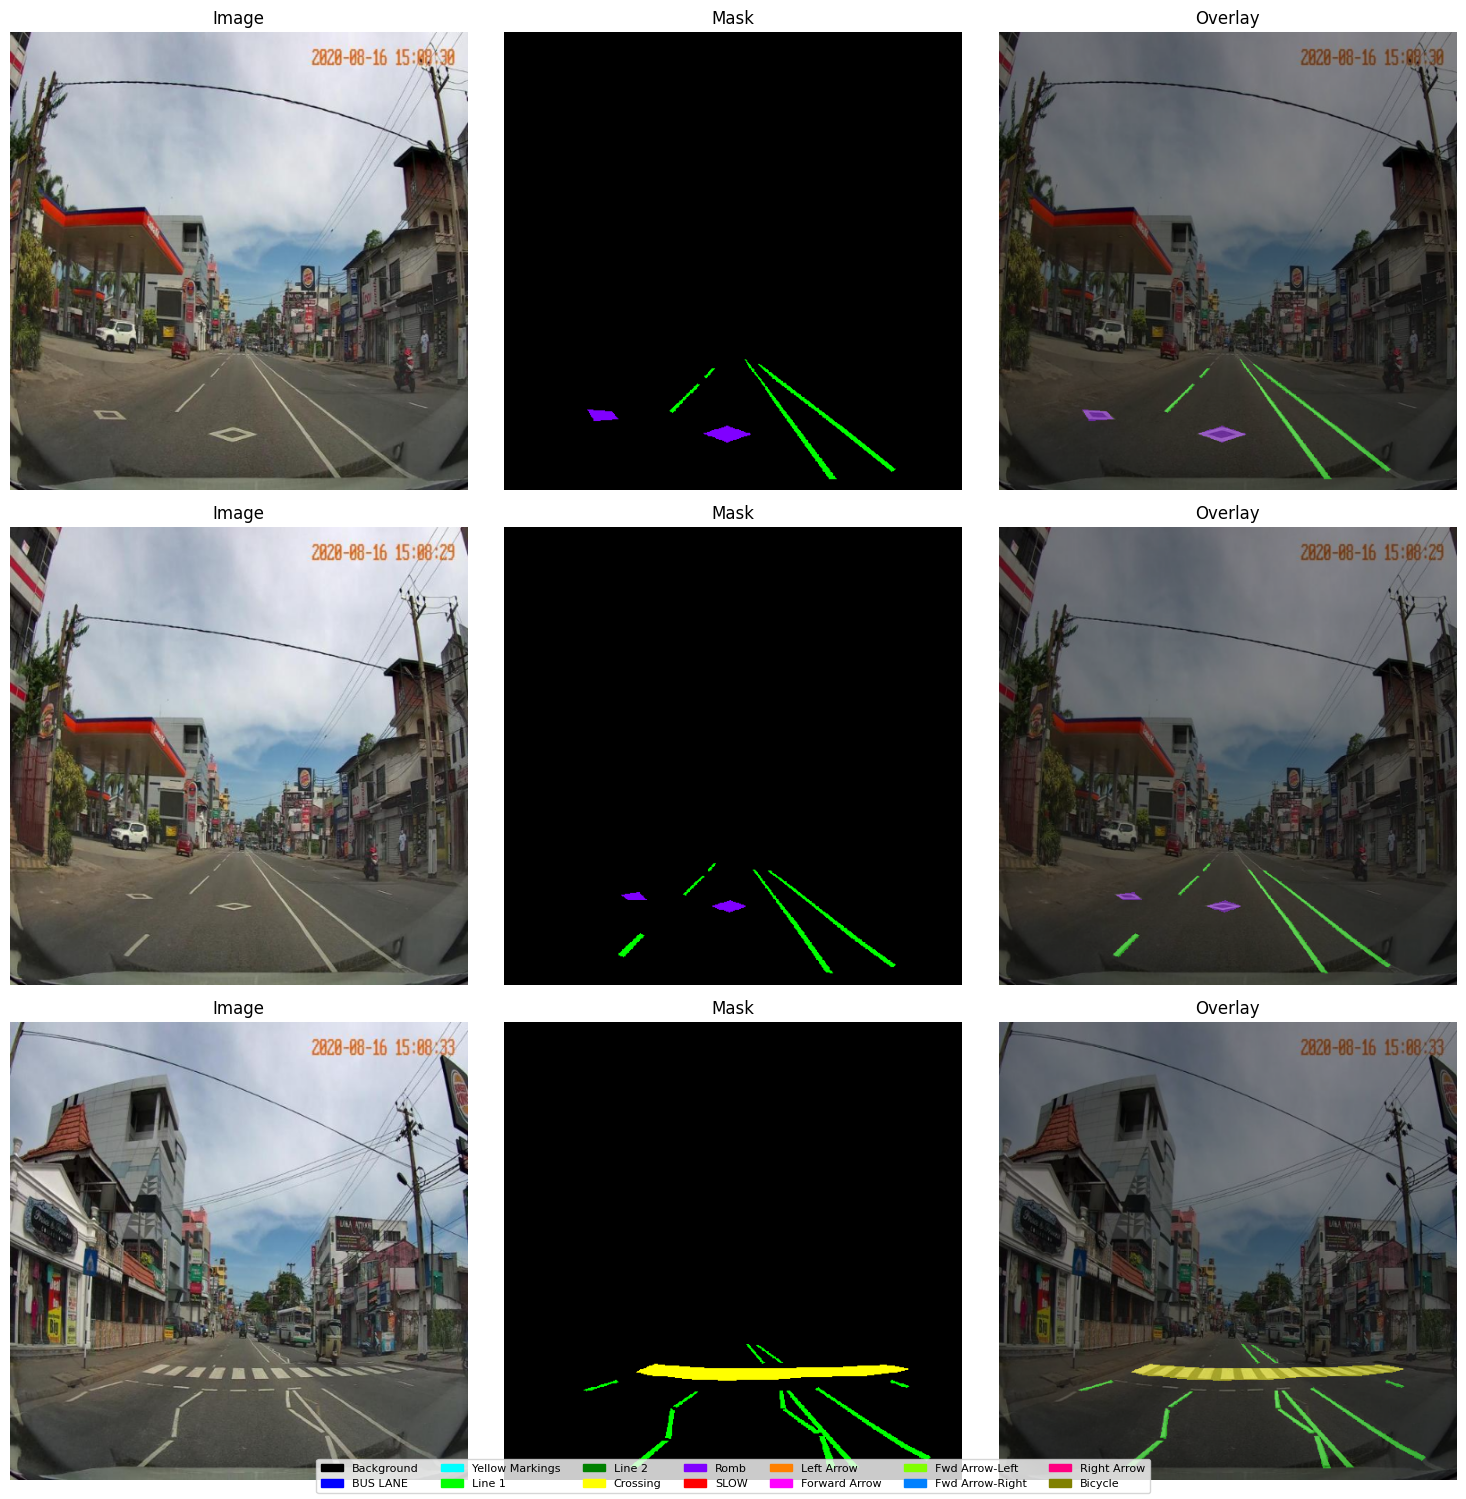

In [6]:
def colorise_mask(mask: np.ndarray) -> np.ndarray:
    colour = np.zeros((*mask.shape, 3), dtype=np.uint8)
    for cls_id, rgb in enumerate(CLASS_COLORS):
        colour[mask == cls_id] = rgb
    return colour


def show_samples(img_dir, mask_dir, n=3):
    paths = sorted(glob.glob(os.path.join(img_dir, '*.jpg')))[:n]
    fig, axes = plt.subplots(n, 3, figsize=(15, 5 * n))
    if n == 1: axes = [axes]

    for i, ip in enumerate(paths):
        stem = Path(ip).stem
        img  = cv2.cvtColor(cv2.imread(ip), cv2.COLOR_BGR2RGB)
        img  = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        mask = cv2.imread(os.path.join(mask_dir, stem + '.png'), cv2.IMREAD_GRAYSCALE)
        col  = colorise_mask(mask)
        ov   = cv2.addWeighted(img, 0.55, col, 0.45, 0)

        axes[i][0].imshow(img);  axes[i][0].set_title('Image')
        axes[i][1].imshow(col);  axes[i][1].set_title('Mask')
        axes[i][2].imshow(ov);   axes[i][2].set_title('Overlay')
        for ax in axes[i]: ax.axis('off')

    patches = [mpatches.Patch(color=np.array(c)/255, label=n_)
               for c, n_ in zip(CLASS_COLORS, CLASS_NAMES)]
    fig.legend(handles=patches, loc='lower center', ncol=7, fontsize=8)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'sample_masks.png'), bbox_inches='tight')
    plt.show()

show_samples(TRAIN_IMG_DIR, TRAIN_MASK_DIR, n=3)

## Cell 6 — Dataset & DataLoaders

In [7]:
class RoadMarkingDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transform=None, img_size=IMG_SIZE):
        self.img_dir   = img_dir
        self.mask_dir  = mask_dir
        self.transform = transform
        self.img_size  = img_size

        all_imgs = sorted(glob.glob(os.path.join(img_dir, '*.jpg')) +
                          glob.glob(os.path.join(img_dir, '*.png')))
        self.img_paths = [
            p for p in all_imgs
            if os.path.exists(os.path.join(mask_dir, Path(p).stem + '.png'))
        ]
        print(f'  [{os.path.basename(img_dir)}] {len(self.img_paths)} samples')

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        ip   = self.img_paths[idx]
        mp   = os.path.join(self.mask_dir, Path(ip).stem + '.png')
        img  = cv2.cvtColor(cv2.imread(ip), cv2.COLOR_BGR2RGB)
        img  = cv2.resize(img, (self.img_size, self.img_size))
        mask = cv2.imread(mp, cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, (self.img_size, self.img_size),
                          interpolation=cv2.INTER_NEAREST)

        if self.transform:
            aug  = self.transform(image=img, mask=mask)
            img, mask = aug['image'], aug['mask']

        return img, mask.long()


MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_tfm = A.Compose([
    A.RandomResizedCrop(size=(IMG_SIZE, IMG_SIZE), scale=(0.5, 1.0)),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.3),
    A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05, p=0.5),
    A.GaussianBlur(blur_limit=(3, 7), p=0.2),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

val_tfm = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

# Domain-adaptation augmentation: simulates UAV top-down perspective
drone_tfm = A.Compose([
    A.RandomResizedCrop(size=(IMG_SIZE, IMG_SIZE), scale=(0.5, 1.0)),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.RandomBrightnessContrast(p=0.4),
    A.HueSaturationValue(hue_shift_limit=15, sat_shift_limit=30, p=0.3),
    A.ISONoise(p=0.2),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

print('Loading datasets...')
train_ds   = RoadMarkingDataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR, transform=train_tfm)
val_ds     = RoadMarkingDataset(VAL_IMG_DIR,   VAL_MASK_DIR,   transform=val_tfm)
test_ds    = RoadMarkingDataset(TEST_IMG_DIR,  TEST_MASK_DIR,  transform=val_tfm)
drone_ds   = RoadMarkingDataset(VAL_IMG_DIR,   VAL_MASK_DIR,   transform=drone_tfm)

train_loader  = DataLoader(train_ds,  batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader    = DataLoader(val_ds,    batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader   = DataLoader(test_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
drone_loader  = DataLoader(drone_ds,  batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)

print(f'Train batches: {len(train_loader)}')
print(f'Val   batches: {len(val_loader)}')
print(f'Test  batches: {len(test_loader)}')

Loading datasets...
  [images] 2167 samples
  [images] 417 samples
  [images] 192 samples
  [images] 417 samples
Train batches: 271
Val   batches: 53
Test  batches: 24


## Cell 7 — DeepLabV3+ Model (ResNet-101 Backbone)

In [8]:
class ASPPConv(nn.Sequential):
    def __init__(self, in_ch, out_ch, dilation):
        super().__init__(
            nn.Conv2d(in_ch, out_ch, 3, padding=dilation, dilation=dilation, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )


class ASPPPooling(nn.Sequential):
    def __init__(self, in_ch, out_ch):
        super().__init__(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_ch, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        size = x.shape[-2:]
        for m in self: x = m(x)
        return F.interpolate(x, size=size, mode='bilinear', align_corners=False)


class ASPP(nn.Module):
    def __init__(self, in_ch=2048, out_ch=256, rates=(6, 12, 18)):
        super().__init__()
        mods = [nn.Sequential(
                    nn.Conv2d(in_ch, out_ch, 1, bias=False),
                    nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True))]
        for r in rates:
            mods.append(ASPPConv(in_ch, out_ch, r))
        mods.append(ASPPPooling(in_ch, out_ch))
        self.convs = nn.ModuleList(mods)
        self.project = nn.Sequential(
            nn.Conv2d(len(mods) * out_ch, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5)
        )

    def forward(self, x):
        return self.project(torch.cat([c(x) for c in self.convs], dim=1))


class DeepLabV3Plus(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, pretrained=True):
        super().__init__()
        bb = models.resnet101(weights='IMAGENET1K_V2' if pretrained else None)

        self.layer0 = nn.Sequential(bb.conv1, bb.bn1, bb.relu, bb.maxpool)
        self.layer1 = bb.layer1   # 256 ch, stride 4
        self.layer2 = bb.layer2   # 512 ch, stride 8
        self.layer3 = bb.layer3   # 1024 ch
        self.layer4 = bb.layer4   # 2048 ch

        # Apply dilated convolutions to layer3 & layer4 (output stride = 16)
        for n, m in self.layer3.named_modules():
            if 'conv2' in n:
                m.dilation = (2, 2); m.padding = (2, 2)
        for n, m in self.layer4.named_modules():
            if 'conv2' in n:
                m.dilation = (4, 4); m.padding = (4, 4)

        self.aspp = ASPP(2048, 256, (6, 12, 18))

        self.low_proj = nn.Sequential(
            nn.Conv2d(256, 48, 1, bias=False),
            nn.BatchNorm2d(48),
            nn.ReLU(inplace=True)
        )

        self.decoder = nn.Sequential(
            nn.Conv2d(256 + 48, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True), nn.Dropout(0.5),
            nn.Conv2d(256, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True), nn.Dropout(0.1),
            nn.Conv2d(256, num_classes, 1)
        )

    def forward(self, x):
        in_size   = x.shape[-2:]
        x         = self.layer0(x)
        low       = self.layer1(x)
        x         = self.layer2(low)
        x         = self.layer3(x)
        x         = self.layer4(x)
        x         = self.aspp(x)
        x         = F.interpolate(x, size=low.shape[-2:], mode='bilinear', align_corners=False)
        low       = self.low_proj(low)
        x         = self.decoder(torch.cat([x, low], dim=1))
        return F.interpolate(x, size=in_size, mode='bilinear', align_corners=False)


model = DeepLabV3Plus(num_classes=NUM_CLASSES, pretrained=True).to(DEVICE)
tp = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {tp/1e6:.2f} M')

Downloading: "https://download.pytorch.org/models/resnet101-cd907fc2.pth" to /root/.cache/torch/hub/checkpoints/resnet101-cd907fc2.pth


100%|██████████| 171M/171M [00:01<00:00, 110MB/s] 


Trainable parameters: 59.34 M


## Cell 8 — Loss Function (Dice + Cross-Entropy)

In [9]:
class DiceLoss(nn.Module):
    def __init__(self, num_classes, smooth=1e-6):
        super().__init__()
        self.C = num_classes
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)
        toh   = F.one_hot(targets.clamp(0, self.C - 1), self.C).permute(0, 3, 1, 2).float()
        inter = (probs * toh).sum(dim=(0, 2, 3))
        union = (probs + toh).sum(dim=(0, 2, 3))
        return 1 - ((2 * inter + self.smooth) / (union + self.smooth)).mean()


class CombinedLoss(nn.Module):
    def __init__(self, num_classes, ce_w=0.6, dice_w=0.4):
        super().__init__()
        self.ce   = nn.CrossEntropyLoss(ignore_index=255)
        self.dice = DiceLoss(num_classes)
        self.ce_w = ce_w; self.dice_w = dice_w

    def forward(self, logits, targets):
        return self.ce_w * self.ce(logits, targets) + self.dice_w * self.dice(logits, targets)


criterion = CombinedLoss(NUM_CLASSES)
print('Loss: 0.6 x CrossEntropy  +  0.4 x DiceLoss')

Loss: 0.6 x CrossEntropy  +  0.4 x DiceLoss


## Cell 9 — mIoU Metric

In [10]:
class IoUMetric:
    def __init__(self, num_classes):
        self.C = num_classes
        self.reset()

    def reset(self):
        self.inter = np.zeros(self.C, dtype=np.float64)
        self.union = np.zeros(self.C, dtype=np.float64)

    def update(self, logits, targets):
        preds   = logits.argmax(1).cpu().numpy().flatten()
        targets = targets.cpu().numpy().flatten()
        for c in range(self.C):
            p = (preds == c); t = (targets == c)
            self.inter[c] += (p & t).sum()
            self.union[c] += (p | t).sum()

    def compute(self):
        iou   = np.where(self.union > 0, self.inter / (self.union + 1e-8), np.nan)
        valid = ~np.isnan(iou)
        miou  = iou[valid].mean() if valid.any() else 0.0
        pc    = {CLASS_NAMES[i]: float(iou[i]) if valid[i] else None for i in range(self.C)}
        return miou, pc

print('IoU metric ready.')

IoU metric ready.


## Cell 10 — Train & Evaluate Helpers

In [11]:
def train_one_epoch(model, loader, optimizer, scheduler, scaler, num_classes):
    model.train()
    total_loss = 0.0
    metric = IoUMetric(num_classes) # Track IoU during training

    for imgs, masks in tqdm(loader, leave=False, desc='Train'):
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            logits = model(imgs)
            loss = criterion(logits, masks)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        metric.update(logits, masks)

    if scheduler:
        scheduler.step()

    avg_loss = total_loss / len(loader)
    miou, _ = metric.compute()
    return avg_loss, miou

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total = 0.0
    metric = IoUMetric(NUM_CLASSES)
    for imgs, masks in tqdm(loader, leave=False, desc='Eval'):
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        with torch.cuda.amp.autocast():
            logits = model(imgs)
            loss   = criterion(logits, masks)
        total += loss.item()
        metric.update(logits, masks)
    miou, pc = metric.compute()
    return total / len(loader), miou, pc


def plot_history(hist, title, path):
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    ax[0].plot(hist['train_loss'], label='Train'); ax[0].plot(hist['val_loss'], label='Val')
    ax[0].set_title(f'{title} - Loss'); ax[0].legend(); ax[0].grid(True)
    ax[1].plot(hist['val_miou'], color='green', label='Val mIoU')
    ax[1].set_title(f'{title} - mIoU'); ax[1].legend(); ax[1].grid(True)
    plt.tight_layout(); plt.savefig(path, bbox_inches='tight'); plt.show()

print('Helper functions ready.')

Helper functions ready.


In [12]:
class EarlyStopping:
    def __init__(self, patience=7, min_delta=0, verbose=True):
        """
        Args:
            patience (int): How many epochs to wait after last time mIoU improved.
            min_delta (float): Minimum change in the monitored quantity to qualify as an improvement.
            verbose (bool): If True, prints a message for each improvement.
        """
        self.patience = patience
        self.min_delta = min_delta
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False

    def __call__(self, val_miou):
        if self.best_score is None:
            self.best_score = val_miou
        elif val_miou < self.best_score + self.min_delta:
            self.counter += 1
            if self.verbose:
                print(f"      EarlyStopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = val_miou
            self.counter = 0

## Cell 11 — Phase 1: Pre-training (CeyMo-style / Train Split)

In [13]:
CKPT_PRE = os.path.join(OUTPUT_DIR, 'best_pretrain.pth')

# If checkpoint exists → load and skip training
if os.path.exists(CKPT_PRE):
    print("Found pretrain checkpoint. Loading...")
    ck = torch.load(CKPT_PRE, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ck['model_state_dict'])
    best_pre = ck.get('val_miou', 0.0)
    print(f"Loaded checkpoint with mIoU = {best_pre:.4f}")
    SKIP_PRETRAIN = True
else:
    print("No checkpoint found. Training from scratch...")
    SKIP_PRETRAIN = False

No checkpoint found. Training from scratch...


In [14]:
backbone_p = (list(model.layer0.parameters()) + list(model.layer1.parameters()) +
              list(model.layer2.parameters()) + list(model.layer3.parameters()) +
              list(model.layer4.parameters()))
head_p     = (list(model.aspp.parameters()) + list(model.low_proj.parameters()) +
              list(model.decoder.parameters()))

opt_pre = optim.AdamW([
    {'params': backbone_p, 'lr': LR * 0.1},
    {'params': head_p,     'lr': LR}
], weight_decay=WEIGHT_DECAY)

sch_pre  = optim.lr_scheduler.CosineAnnealingLR(opt_pre, T_max=PRETRAIN_EPOCHS, eta_min=1e-6)
scaler   = torch.cuda.amp.GradScaler()

best_pre = 0.0
CKPT_PRE = os.path.join(OUTPUT_DIR, 'best_pretrain.pth')

print('PHASE 1 -- PRE-TRAINING  (CeyMo-style, train split)')

early_stopping_pre = EarlyStopping(patience=5, verbose=True)

hist_pre = {'epoch': [], 'train_loss': [], 'train_miou': [], 'val_loss': [], 'val_miou': []}
LOG_FILE_PRE = os.path.join(OUTPUT_DIR, 'phase1_metrics.csv')

if not SKIP_PRETRAIN:

  for epoch in range(1, PRETRAIN_EPOCHS + 1):
    t0 = time.time()

    tl, tm_train = train_one_epoch(model, train_loader, opt_pre, sch_pre, scaler, NUM_CLASSES)
    vl, vm_val, pc = evaluate(model, val_loader)

    hist_pre['epoch'].append(epoch)
    hist_pre['train_loss'].append(tl)
    hist_pre['train_miou'].append(tm_train)
    hist_pre['val_loss'].append(vl)
    hist_pre['val_miou'].append(vm_val)

    pd.DataFrame(hist_pre).to_csv(LOG_FILE_PRE, index=False)

    print(f'Epoch [{epoch:03d}] Train Loss: {tl:.4f} | Train mIoU: {tm_train:.4f} | Val mIoU: {vm_val:.4f} ({time.time()-t0:.1f}s)')

    if vm_val > best_pre:
      best_pre = vm_val
      torch.save({
          'epoch': epoch,
          'model_state_dict': model.state_dict(),
          'val_miou': vm_val
      }, CKPT_PRE)
      print(f'  >> Best model saved (mIoU = {vm_val:.4f})')

    early_stopping_pre(vm_val)
    if early_stopping_pre.early_stop:
            print("Early stopping triggered. Ending Phase 1.")
            break
else:
    print("Skipping pretraining (checkpoint already loaded)")

print(f'\nPre-training done.  Best mIoU = {best_pre:.4f}')
# plot_history(hist_pre, 'Phase 1 Pre-training', os.path.join(OUTPUT_DIR, 'phase1_history.png'))

PHASE 1 -- PRE-TRAINING  (CeyMo-style, train split)


Train:   0%|          | 0/271 [00:00<?, ?it/s]

Eval:   0%|          | 0/53 [00:00<?, ?it/s]

Epoch [001] Train Loss: 0.8148 | Train mIoU: 0.0761 | Val mIoU: 0.1263 (717.8s)
  >> Best model saved (mIoU = 0.1263)


Train:   0%|          | 0/271 [00:00<?, ?it/s]

...

Eval:   0%|          | 0/53 [00:00<?, ?it/s]

Epoch [039] Train Loss: 0.2430 | Train mIoU: 0.7220 | Val mIoU: 0.6386 (165.9s)
      EarlyStopping counter: 4 out of 5


Train:   0%|          | 0/271 [00:00<?, ?it/s]

Eval:   0%|          | 0/53 [00:00<?, ?it/s]

Epoch [040] Train Loss: 0.2434 | Train mIoU: 0.7242 | Val mIoU: 0.6459 (166.7s)
      EarlyStopping counter: 5 out of 5
Early stopping triggered. Ending Phase 1.

Pre-training done.  Best mIoU = 0.6461


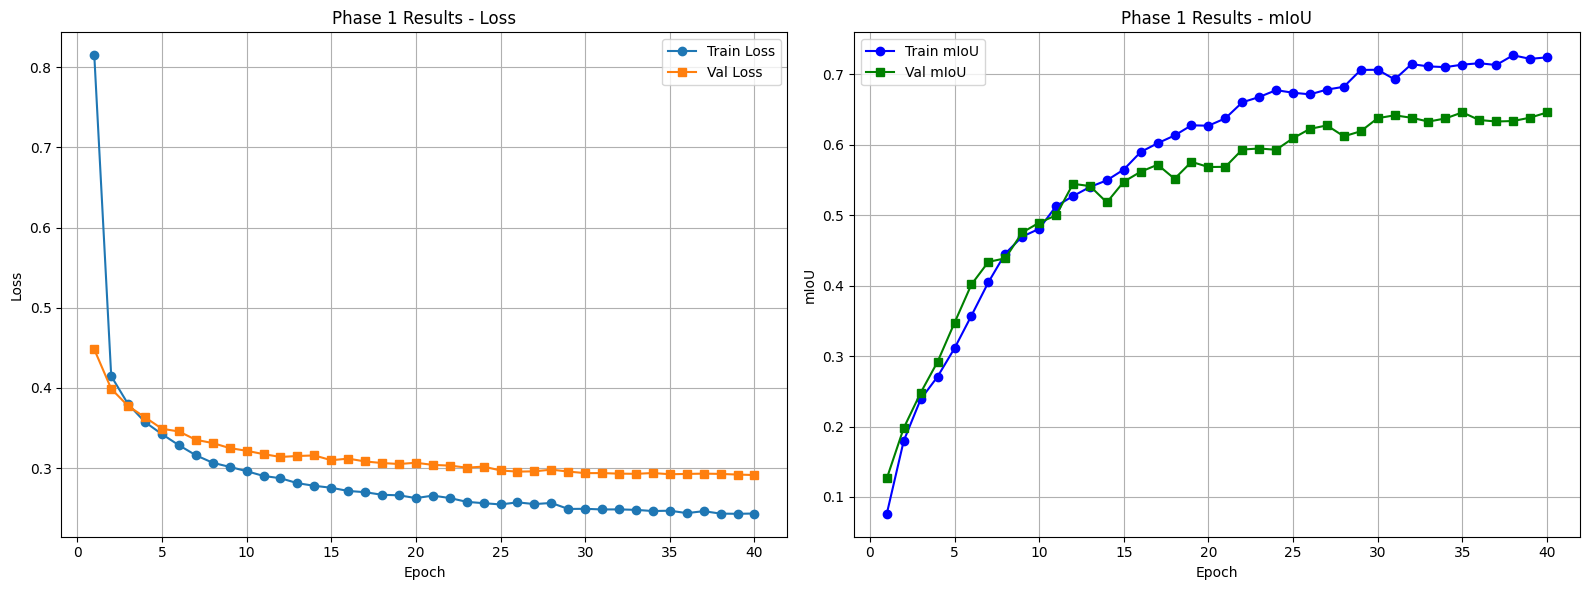

In [15]:
def fetch_and_visualize(csv_path, title):
    if not os.path.exists(csv_path):
        print(f"File {csv_path} not found.")
        return

    # Load data from Drive
    df = pd.read_csv(csv_path)

    fig, ax = plt.subplots(1, 2, figsize=(16, 6))

    # Plot Losses
    ax[0].plot(df['epoch'], df['train_loss'], label='Train Loss', marker='o')
    ax[0].plot(df['epoch'], df['val_loss'], label='Val Loss', marker='s')
    ax[0].set_title(f'{title} - Loss')
    ax[0].set_xlabel('Epoch')
    ax[0].set_ylabel('Loss')
    ax[0].legend()
    ax[0].grid(True)

    # Plot mIoU
    ax[1].plot(df['epoch'], df['train_miou'], label='Train mIoU', color='blue', marker='o')
    ax[1].plot(df['epoch'], df['val_miou'], label='Val mIoU', color='green', marker='s')
    ax[1].set_title(f'{title} - mIoU')
    ax[1].set_xlabel('Epoch')
    ax[1].set_ylabel('mIoU')
    ax[1].legend()
    ax[1].grid(True)

    plt.tight_layout()
    plt.show()

# To use it:
fetch_and_visualize(os.path.join(OUTPUT_DIR, 'phase1_metrics.csv'), 'Phase 1 Results')

## Cell 12 — Phase 2: Fine-tuning on AU Drone Data (Domain Adaptation)

In [16]:
CKPT_FT = os.path.join(OUTPUT_DIR, 'best_finetune.pth')

if os.path.exists(CKPT_FT):
    print("✅ Found fine-tuned checkpoint. Loading...")
    ck = torch.load(CKPT_FT, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ck['model_state_dict'])
    best_ft = ck.get('val_miou', 0.0)
    print(f"Loaded fine-tuned model mIoU = {best_ft:.4f}")
    SKIP_FINETUNE = True
else:
    print("❌ No fine-tuned checkpoint found. Running fine-tuning...")
    SKIP_FINETUNE = False

❌ No fine-tuned checkpoint found. Running fine-tuning...


In [17]:
# Load best pre-trained weights
ck = torch.load(CKPT_PRE, map_location=DEVICE, weights_only=False)
model.load_state_dict(ck['model_state_dict'])
print(f'Loaded pre-trained checkpoint (mIoU = {ck["val_miou"]:.4f})')

def freeze_backbone(m, freeze=True):
    for layer in [m.layer0, m.layer1, m.layer2, m.layer3, m.layer4]:
        for p in layer.parameters():
            p.requires_grad = not freeze

freeze_backbone(model, True)  # start with frozen backbone

opt_ft    = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                        lr=LR * 0.5, weight_decay=WEIGHT_DECAY)
sch_ft    = optim.lr_scheduler.OneCycleLR(opt_ft, max_lr=LR * 0.5,
                                           steps_per_epoch=len(train_loader),
                                           epochs=FINETUNE_EPOCHS)
scaler_ft = torch.cuda.amp.GradScaler()

hist_ft = {'epoch': [], 'train_loss': [], 'train_miou': [], 'val_loss': [], 'val_miou': []}
LOG_FILE_FT = os.path.join(OUTPUT_DIR, 'phase2_metrics.csv')
best_ft = 0.0

CKPT_FT = os.path.join(OUTPUT_DIR, 'best_finetune.pth')
UNFREEZE_AT = 5

print('PHASE 2 -- FINE-TUNING  (same dataset, stronger augmentation)')

early_stopping_ft = EarlyStopping(patience=5, verbose=True)

if not SKIP_FINETUNE:
    for epoch in range(1, FINETUNE_EPOCHS + 1):

      if epoch == UNFREEZE_AT + 1:
        freeze_backbone(model, False)
        opt_ft = optim.AdamW([
            {'params': (list(model.layer0.parameters()) + list(model.layer1.parameters()) +
                        list(model.layer2.parameters()) + list(model.layer3.parameters()) +
                        list(model.layer4.parameters())), 'lr': LR * 0.05},
            {'params': (list(model.aspp.parameters()) + list(model.low_proj.parameters()) +
                        list(model.decoder.parameters())), 'lr': LR * 0.2}
        ], weight_decay=WEIGHT_DECAY)
        print(f'  >> Backbone unfrozen at epoch {epoch}')

      t0 = time.time()
      tl, tm_train = train_one_epoch(model, train_loader, opt_ft,
                                       sch_ft if epoch <= UNFREEZE_AT else None,
                                       scaler_ft, NUM_CLASSES)
      vl, vm, pc = evaluate(model, val_loader)

      hist_ft['epoch'].append(epoch)
      hist_ft['train_loss'].append(tl)
      hist_ft['train_miou'].append(tm_train)
      hist_ft['val_loss'].append(vl)
      hist_ft['val_miou'].append(vm)

      pd.DataFrame(hist_ft).to_csv(LOG_FILE_FT, index=False)

      print(f'Epoch [{epoch:03d}/{FINETUNE_EPOCHS}] Train Loss: {tl:.4f} | Train mIoU: {tm_train:.4f} | Val mIoU: {vm:.4f} ({time.time()-t0:.1f}s)')

      if vm > best_ft:
            best_ft = vm
            torch.save({'epoch': epoch, 'model_state_dict': model.state_dict(), 'val_miou': vm}, CKPT_FT)
            print(f'  >> Best model saved (mIoU = {vm:.4f})')

      if epoch > UNFREEZE_AT:
            early_stopping_ft(vm)
            if early_stopping_ft.early_stop:
                print("Early stopping triggered. Ending Phase 2.")
                break
else:
    print("Skipping fine-tuning (checkpoint already loaded)")

print(f'\nFine-tuning done.  Best mIoU = {best_ft:.4f}')
# plot_history(hist_ft, 'Phase 2 Fine-tuning', os.path.join(OUTPUT_DIR, 'phase2_history.png'))

Loaded pre-trained checkpoint (mIoU = 0.6461)
PHASE 2 -- FINE-TUNING  (same dataset, stronger augmentation)


Train:   0%|          | 0/271 [00:00<?, ?it/s]

Eval:   0%|          | 0/53 [00:00<?, ?it/s]

Epoch [001/50] Train Loss: 0.2438 | Train mIoU: 0.7171 | Val mIoU: 0.6441 (120.8s)
  >> Best model saved (mIoU = 0.6441)


Train:   0%|          | 0/271 [00:00<?, ?it/s]

...

Eval:   0%|          | 0/53 [00:00<?, ?it/s]

Epoch [016/50] Train Loss: 0.2396 | Train mIoU: 0.7398 | Val mIoU: 0.6584 (159.6s)
      EarlyStopping counter: 4 out of 5


Train:   0%|          | 0/271 [00:00<?, ?it/s]

Eval:   0%|          | 0/53 [00:00<?, ?it/s]

Epoch [017/50] Train Loss: 0.2412 | Train mIoU: 0.7359 | Val mIoU: 0.6539 (165.1s)
      EarlyStopping counter: 5 out of 5
Early stopping triggered. Ending Phase 2.

Fine-tuning done.  Best mIoU = 0.6621


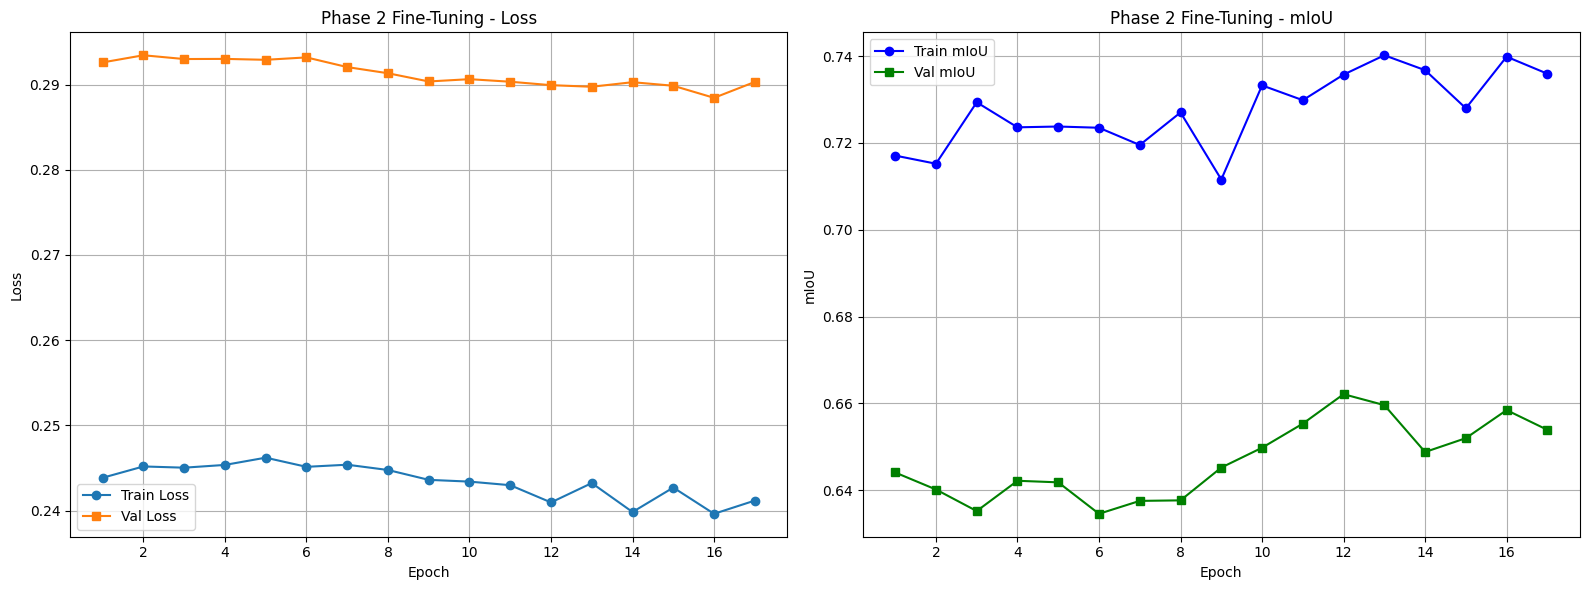

In [18]:
def visualize_metrics(csv_path, title):
    if not os.path.exists(csv_path):
        print(f"No log file found at {csv_path}")
        return

    df = pd.read_csv(csv_path)
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))

    # 1. Plot Loss
    ax[0].plot(df['epoch'], df['train_loss'], label='Train Loss', marker='o')
    ax[0].plot(df['epoch'], df['val_loss'], label='Val Loss', marker='s')
    ax[0].set_title(f'{title} - Loss')
    ax[0].set_xlabel('Epoch'); ax[0].set_ylabel('Loss')
    ax[0].legend(); ax[0].grid(True)

    # 2. Plot mIoU
    ax[1].plot(df['epoch'], df['train_miou'], label='Train mIoU', color='blue', marker='o')
    ax[1].plot(df['epoch'], df['val_miou'], label='Val mIoU', color='green', marker='s')
    ax[1].set_title(f'{title} - mIoU')
    ax[1].set_xlabel('Epoch'); ax[1].set_ylabel('mIoU')
    ax[1].legend(); ax[1].grid(True)

    plt.tight_layout()
    plt.show()

# Visualize Phase 2
visualize_metrics(os.path.join(OUTPUT_DIR, 'phase2_metrics.csv'), 'Phase 2 Fine-Tuning')

## Cell 13 — Comparative mIoU Analysis (Before vs After Fine-tuning)

Eval:   0%|          | 0/24 [00:00<?, ?it/s]

Before fine-tuning  ->  mIoU = 0.6605


Eval:   0%|          | 0/24 [00:00<?, ?it/s]

After  fine-tuning  ->  mIoU = 0.6716


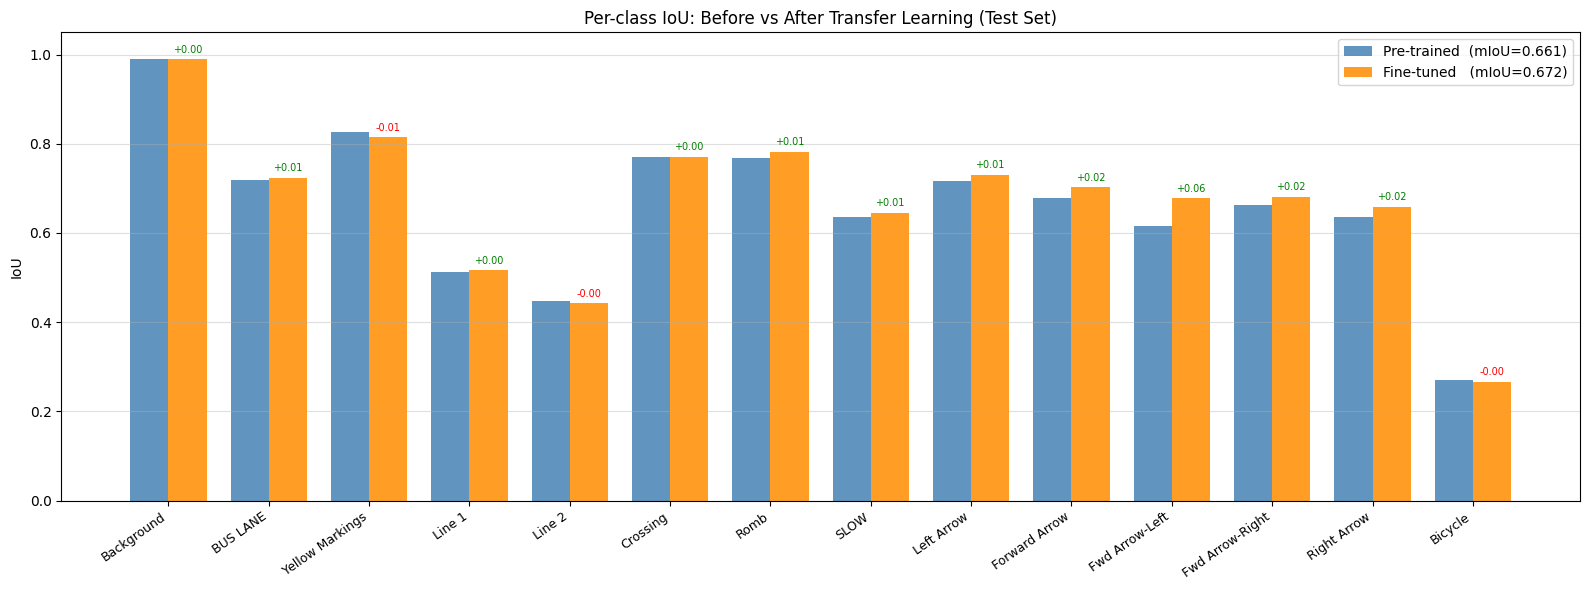


Overall improvement: 0.6605 -> 0.6716  (delta = +0.0111)


In [19]:
@torch.no_grad()
def eval_ckpt(path, loader, label):
    m = DeepLabV3Plus(num_classes=NUM_CLASSES, pretrained=False).to(DEVICE)
    ckpt = torch.load(path, map_location=DEVICE, weights_only=False)
    m.load_state_dict(ckpt['model_state_dict'])
    m.eval()
    _, miou, pc = evaluate(m, loader)
    print(f'{label}  ->  mIoU = {miou:.4f}')
    return miou, pc

miou_before, pc_before = eval_ckpt(CKPT_PRE, test_loader, 'Before fine-tuning')
miou_after,  pc_after  = eval_ckpt(CKPT_FT,  test_loader, 'After  fine-tuning')

valid_cls = [c for c in CLASS_NAMES if pc_before.get(c) is not None and pc_after.get(c) is not None]
iou_b = [pc_before[c] for c in valid_cls]
iou_a = [pc_after[c]  for c in valid_cls]
x     = np.arange(len(valid_cls))
w     = 0.38

fig, ax = plt.subplots(figsize=(16, 6), facecolor='none')
ax.set_facecolor('none')
ax.bar(x - w/2, iou_b, w, label=f'Pre-trained  (mIoU={miou_before:.3f})', color='steelblue', alpha=0.85)
ax.bar(x + w/2, iou_a, w, label=f'Fine-tuned   (mIoU={miou_after:.3f})',  color='darkorange', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(valid_cls, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('IoU'); ax.set_title('Per-class IoU: Before vs After Transfer Learning (Test Set)')
ax.legend(); ax.grid(axis='y', alpha=0.4); ax.set_ylim(0, 1.05)
for xi, (b, a) in enumerate(zip(iou_b, iou_a)):
    ax.annotate(f'{a-b:+.2f}', xy=(xi+w/2, a+0.01), ha='center', va='bottom',
                fontsize=7, color='green' if a >= b else 'red')
plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, 'miou_comparison.png'),
    bbox_inches='tight',
    dpi=150,
    transparent=True
)
plt.show()
print(f'\nOverall improvement: {miou_before:.4f} -> {miou_after:.4f}  (delta = {miou_after-miou_before:+.4f})')

## Cell 14 — Inference & Visualisation

In [20]:
@torch.no_grad()
def predict(model, img_path):
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    t   = A.Compose([A.Normalize(mean=MEAN, std=STD), ToTensorV2()])(image=img)['image']
    model.eval()
    return img, model(t.unsqueeze(0).to(DEVICE)).argmax(1).squeeze().cpu().numpy().astype(np.uint8)


def show_inference(ckpt_path, img_paths, title, n=4):
    m = DeepLabV3Plus(num_classes=NUM_CLASSES, pretrained=False).to(DEVICE)
    ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    m.load_state_dict(ckpt['model_state_dict'])
    chosen = random.sample(img_paths, min(n, len(img_paths)))
    fig, axes = plt.subplots(n, 3, figsize=(15, 5 * n))
    if n == 1: axes = [axes]
    for i, ip in enumerate(chosen):
        img, pred = predict(m, ip)
        col = colorise_mask(pred)
        ov  = cv2.addWeighted(img, 0.55, col, 0.45, 0)
        axes[i][0].imshow(img);  axes[i][0].set_title('Input')
        axes[i][1].imshow(col);  axes[i][1].set_title('Prediction')
        axes[i][2].imshow(ov);   axes[i][2].set_title('Overlay')
        for ax in axes[i]: ax.axis('off')
    patches = [mpatches.Patch(color=np.array(c)/255, label=n_)
               for c, n_ in zip(CLASS_COLORS, CLASS_NAMES)]
    fig.legend(handles=patches, loc='lower center', ncol=7, fontsize=8)
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'infer_{title[:12].replace(" ","_")}.png'), bbox_inches='tight')
    plt.show()


test_imgs = sorted(glob.glob(os.path.join(TEST_IMG_DIR, '*.jpg')))
show_inference(CKPT_PRE, test_imgs, 'Before Fine-tuning', n=4)
show_inference(CKPT_FT,  test_imgs, 'After Fine-tuning',  n=4)

Output hidden; open in https://colab.research.google.com to view.

## Cell 15 — Side-by-Side Before vs After Comparison

In [21]:
def compare_models(ckpt_pre, ckpt_ft, img_paths, n=4):
    m_pre = DeepLabV3Plus(NUM_CLASSES, False).to(DEVICE)
    ckpt1 = torch.load(ckpt_pre, map_location=DEVICE, weights_only=False)
    m_pre.load_state_dict(ckpt1['model_state_dict'])

    m_ft = DeepLabV3Plus(NUM_CLASSES, False).to(DEVICE)
    ckpt2 = torch.load(ckpt_ft, map_location=DEVICE, weights_only=False)
    m_ft.load_state_dict(ckpt2['model_state_dict'])

    chosen = random.sample(img_paths, min(n, len(img_paths)))
    fig, axes = plt.subplots(n, 4, figsize=(20, 5 * n))

    if n == 1:
        axes = [axes]

    for i, ip in enumerate(chosen):
        img, pp = predict(m_pre, ip)
        _,   fp = predict(m_ft, ip)

        axes[i][0].imshow(img);               axes[i][0].set_title('Input')
        axes[i][1].imshow(colorise_mask(pp)); axes[i][1].set_title('Pre-trained')
        axes[i][2].imshow(colorise_mask(fp)); axes[i][2].set_title('Fine-tuned')
        axes[i][3].imshow(cv2.addWeighted(img, 0.5, colorise_mask(fp), 0.5, 0))
        axes[i][3].set_title('Fine-tuned Overlay')

        for ax in axes[i]:
            ax.axis('off')

    patches = [mpatches.Patch(color=np.array(c)/255, label=n_)
               for c, n_ in zip(CLASS_COLORS, CLASS_NAMES)]

    fig.legend(handles=patches, loc='lower center', ncol=7, fontsize=8)
    plt.suptitle('Before vs After Transfer Learning', fontsize=14, fontweight='bold')
    plt.tight_layout()

    plt.savefig(os.path.join(OUTPUT_DIR, 'before_vs_after.png'),
                bbox_inches='tight')
    plt.show()

compare_models(CKPT_PRE, CKPT_FT, test_imgs, n=4)

Output hidden; open in https://colab.research.google.com to view.

## Cell 16 — Pseudo-label Generator (for Unlabelled AU Drone Frames)

In [22]:
@torch.no_grad()
def generate_pseudo_labels(ckpt_path, unlabelled_dir, out_dir, threshold=0.75):
    """
    Run the fine-tuned model over unlabelled UAV images and save pseudo-masks.
    Pixels with max-softmax confidence < threshold are marked 255 (ignore).
    These masks can be reviewed / corrected in CVAT before self-training.
    """
    os.makedirs(out_dir, exist_ok=True)
    m = DeepLabV3Plus(NUM_CLASSES, False).to(DEVICE)
    m.load_state_dict(torch.load(ckpt_path, map_location=DEVICE)['model_state_dict'])
    m.eval()

    tfm = A.Compose([A.Resize(IMG_SIZE, IMG_SIZE), A.Normalize(mean=MEAN, std=STD), ToTensorV2()])
    for ip in tqdm(sorted(glob.glob(os.path.join(unlabelled_dir, '*.jpg')) +
                          glob.glob(os.path.join(unlabelled_dir, '*.png'))),
                   desc='Pseudo-labels'):
        stem = Path(ip).stem
        img  = cv2.cvtColor(cv2.imread(ip), cv2.COLOR_BGR2RGB)
        t    = tfm(image=img)['image'].unsqueeze(0).to(DEVICE)
        probs = F.softmax(m(t), dim=1)
        conf, pred = probs.max(dim=1)
        pred = pred.squeeze().cpu().numpy().astype(np.uint8)
        pred[conf.squeeze().cpu().numpy() < threshold] = 255  # mark uncertain pixels
        cv2.imwrite(os.path.join(out_dir, stem + '.png'), pred)

    print(f'Pseudo-labels saved -> {out_dir}')


# USAGE: point unlabelled_dir at your actual AU Drone unlabelled images
# generate_pseudo_labels(
#     ckpt_path      = CKPT_FT,
#     unlabelled_dir = '/content/drive/MyDrive/CVRoadMarkDetection/au_drone/images',
#     out_dir        = os.path.join(OUTPUT_DIR, 'pseudo_labels'),
#     threshold      = 0.75
# )
print('Pseudo-label function defined. Uncomment the call above with your AU Drone path.')

Pseudo-label function defined. Uncomment the call above with your AU Drone path.


## Cell 17 — Final Summary Report

In [23]:
print('=' * 65)
print('   ROAD MARKING SEGMENTATION - FINAL SUMMARY')
print('=' * 65)
print(f'  Model           : DeepLabV3+ (ResNet-101)')
print(f'  Classes         : {NUM_CLASSES}  (background + 13 road markings)')
print(f'  Input size      : {IMG_SIZE} x {IMG_SIZE}')
print(f'  Loss            : 0.6 x CrossEntropy + 0.4 x Dice')
print(f'  Pre-train epochs: {PRETRAIN_EPOCHS}')
print(f'  Fine-tune epochs: {FINETUNE_EPOCHS}')
print()
print(f'  Test mIoU (before fine-tuning) : {miou_before:.4f}')
print(f'  Test mIoU (after  fine-tuning) : {miou_after:.4f}')
print(f'  Improvement  (delta mIoU)      : {miou_after - miou_before:+.4f}')
print()
print('  Per-class IoU after fine-tuning:')
for cls, iou in pc_after.items():
    v = iou or 0.0
    print(f'    {cls:<22} {v:.3f}')
print()
print(f'  Outputs: {OUTPUT_DIR}')
print('  Files  : best_pretrain.pth  best_finetune.pth')
print('           phase1_history.png  phase2_history.png')
print('           miou_comparison.png  before_vs_after.png')
print('=' * 65)

   ROAD MARKING SEGMENTATION - FINAL SUMMARY
  Model           : DeepLabV3+ (ResNet-101)
  Classes         : 14  (background + 13 road markings)
  Input size      : 512 x 512
  Loss            : 0.6 x CrossEntropy + 0.4 x Dice
  Pre-train epochs: 50
  Fine-tune epochs: 50

  Test mIoU (before fine-tuning) : 0.6605
  Test mIoU (after  fine-tuning) : 0.6716
  Improvement  (delta mIoU)      : +0.0111

  Per-class IoU after fine-tuning:
    Background             0.990
    BUS LANE               0.724
    Yellow Markings        0.814
    Line 1                 0.517
    Line 2                 0.443
    Crossing               0.771
    Romb                   0.782
    SLOW                   0.645
    Left Arrow             0.731
    Forward Arrow          0.702
    Fwd Arrow-Left         0.678
    Fwd Arrow-Right        0.682
    Right Arrow            0.659
    Bicycle                0.266

  Outputs: /content/drive/MyDrive/CVRoadMarkDetection/DeepLabV3+/DeepLabV3+ - Training 4
  Files  : 

In [ ]:
import cv2
import torch
import numpy as np
from tqdm import tqdm
import albumentations as A
from albumentations.pytorch import ToTensorV2

@torch.no_grad()
def process_video(model_path, input_video_path, output_video_path, device=DEVICE):
    # 1. Load the Model
    model = DeepLabV3Plus(num_classes=NUM_CLASSES, pretrained=False).to(device)
    checkpoint = torch.load(model_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    print(f"Loaded model from {model_path}")

    # 2. Open Video Stream
    cap = cv2.VideoCapture(input_video_path)
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps    = int(cap.get(cv2.CAP_PROP_FPS))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # 3. Define Video Writer
    fourcc = cv2.VideoWriter_fourcc(*'mp4v') # Codec for .mp4
    out = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

    # 4. Preprocessing Transform (Must match training)
    transform = A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ])

    print(f"Processing {total_frames} frames...")

    for _ in tqdm(range(total_frames)):
        ret, frame = cap.read()
        if not ret:
            break

        # Convert BGR to RGB for the model
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        # Preprocess
        input_tensor = transform(image=frame_rgb)['image'].unsqueeze(0).to(device)

        # Inference
        logits = model(input_tensor)
        mask = logits.argmax(1).squeeze().cpu().numpy().astype(np.uint8)

        # Colorize the mask
        colored_mask = colorise_mask(mask)

        # Resize mask back to original frame size
        colored_mask_resized = cv2.resize(colored_mask, (width, height), interpolation=cv2.INTER_NEAREST)

        # Overlay: Original Frame * 0.6 + Mask * 0.4
        # Note: colored_mask_resized is RGB, frame is BGR. Convert mask to BGR for overlay.
        mask_bgr = cv2.cvtColor(colored_mask_resized, cv2.COLOR_RGB2BGR)
        overlay = cv2.addWeighted(frame, 0.6, mask_bgr, 0.4, 0)

        # Write frame to output video
        out.write(overlay)

    cap.release()
    out.release()
    print(f"\nDone! Video saved to: {output_video_path}")

# --- EXECUTION ---
# Change these paths to your actual file locations
INPUT_VID = '/content/drive/MyDrive/CVRoadMarkDetection/videos/3.webm'
OUTPUT_VID = '/content/drive/MyDrive/CVRoadMarkDetection/videos/DeepLabV3+/3_deepLabV3_detected.mp4'

# process_video(CKPT_FT, INPUT_VID, OUTPUT_VID)

Loaded model from /content/drive/MyDrive/CVRoadMarkDetection/DeepLabV3+/DeepLabV3+ - Training 4/best_finetune.pth
Processing 1797 frames...


100%|█████████▉| 1796/1797 [02:07<00:00, 14.13it/s]


Done! Video saved to: /content/drive/MyDrive/CVRoadMarkDetection/videos/DeepLabV3+/3_deepLabV3_detected.mp4
